In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import locale
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('HouseData.csv').iloc[:,1:]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25155 entries, 0 to 25154
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   district                  25155 non-null  object
 1   price                     25155 non-null  object
 2   address                   25155 non-null  object
 3   AdUpdateDate              25155 non-null  object
 4   Category                  25155 non-null  object
 5   GrossSquareMeters         25155 non-null  object
 6   BuildingAge               25155 non-null  object
 7   NumberFloorsofBuilding    25155 non-null  int64 
 8   UsingStatus               25155 non-null  object
 9   EligibilityForInvestment  21506 non-null  object
 10  BuildStatus               11231 non-null  object
 11  TitleStatus               9712 non-null   object
 12  ItemStatus                18332 non-null  object
 13  NumberOfBathrooms         25155 non-null  object
 14  NumberOfWCs           

In [7]:
df.head()

,district,price,address,AdUpdateDate,Category,GrossSquareMeters,BuildingAge,NumberFloorsofBuilding,UsingStatus,EligibilityForInvestment,BuildStatus,TitleStatus,ItemStatus,NumberOfBathrooms,NumberOfWCs,AdCreationDate,Type,NetSquareMeters,NumberOfRooms,FloorLocation,HeatingType,CreditEligibility,InsideTheSite,StructureType,MortgageStatus,Swap,Balcony,PriceStatus,RentalIncome,NumberOfBalconies,BalconyType,HallSquareMeters,WCSquareMeters,IsItVideoNavigable?,Subscription,BathroomSquareMeters,BalconySquareMeters
0,adalar,"3,100,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",24 Şubat 2022,Satılık,160 m2,21 Ve Üzeri,3,Mülk Sahibi Oturuyor,Bilinmiyor,NaN,NaN,Eşyalı,2,NaN,24 Şubat 2022,Konut,120 m2,3+1,Çatı Katı,Kombi Doğalgaz,Krediye Uygun,Hayır,NaN,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adalar,"1,600,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",02 Mart 2022,Satılık,120 m2,5-10,3,Mülk Sahibi Oturuyor,Yatırıma Uygun,İkinci El,Kat Mülkiyeti,Eşyalı,1,1,21 Şubat 2022,Konut,100 m2,2+1,Bahçe Katı,Kombi Doğalgaz,Krediye Uygun,Hayır,Betonarme,Yok,Yok,Var,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,adalar,"18,500,000TL","['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",11 Şubat 2022,Satılık,350 m2,21 Ve Üzeri,2,Mülk Sahibi Oturuyor,Bilinmiyor,NaN,NaN,Boş,3,NaN,11 Şubat 2022,Konut,300 m2,3+1,Düz Giriş,Kombi Doğalgaz,Krediye Uygun,Hayır,NaN,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,adalar,"9,500,000TL","['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",11 Şubat 2022,Satılık,550 m2,11-15,3,Mülk Sahibi Oturuyor,Bilinmiyor,İkinci El,NaN,NaN,4,NaN,03 Şubat 2022,Konut,540 m2,8+ Oda,Düz Giriş,Kombi Doğalgaz,Krediye Uygun Değil,Hayır,Betonarme,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,adalar,"25,000,000TL","['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",19 Ocak 2022,Satılık,840 m2,21 Ve Üzeri,4,Boş,Bilinmiyor,İkinci El,NaN,NaN,3,NaN,19 Ocak 2022,Konut,700 m2,8+ Oda,Düz Giriş,Isıtma Yok,Krediye Uygun,Hayır,Ahşap,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# "... TL" Temizleme İşlemi

In [10]:
def clean_price(val):
    try:
        if pd.isna(val):
            return np.nan
        val_str = str(val)
        # İçindeki ilk sayıyı, ondalıklı da olabilir, yakala
        match = re.search(r"\d+[\.,]?\d*", val_str.replace('.', '').replace(',', ''))
        if match:
            return float(match.group(0))
        else:
            return np.nan
    except:
        return np.nan

In [12]:
df.price = df.price.apply(clean_price)

In [14]:
df.price

0         3100000.0
1         1600000.0
2        18500000.0
3         9500000.0
4        25000000.0
            ...    
25150     1850000.0
25151     1100000.0
25152     9000000.0
25153    13000000.0
25154     1000000.0
Name: price, Length: 25155, dtype: float64

# "... m2" Temizleme İşlemi

In [17]:
def clean_m2(val):
    try:
        if pd.isna(val):
            return np.nan
        val_str = str(val)
        match = re.search(r"\d+[\.,]?\d*", val_str)
        if match:
            return float(match.group(0).replace(",", "."))
        else:
            return np.nan
    except:
        return np.nan

In [19]:
m2_cols = ['GrossSquareMeters','NetSquareMeters','HallSquareMeters','WCSquareMeters','BathroomSquareMeters','BalconySquareMeters']

In [21]:
for col in m2_cols:
    clean_col_name=f"{col}_clean"
    df[clean_col_name]=df[col].apply(clean_m2)

In [23]:
df[[f"{col}_clean" for col in m2_cols]].head()

,GrossSquareMeters_clean,NetSquareMeters_clean,HallSquareMeters_clean,WCSquareMeters_clean,BathroomSquareMeters_clean,BalconySquareMeters_clean
0,160.0,120.0,NaN,NaN,NaN,NaN
1,120.0,100.0,NaN,NaN,NaN,NaN
2,350.0,300.0,NaN,NaN,NaN,NaN
3,550.0,540.0,NaN,NaN,NaN,NaN
4,840.0,700.0,NaN,NaN,NaN,NaN


In [27]:
df.drop(m2_cols,axis=1,inplace=True)

In [31]:
df.head()

,district,price,address,AdUpdateDate,Category,BuildingAge,NumberFloorsofBuilding,UsingStatus,EligibilityForInvestment,BuildStatus,TitleStatus,ItemStatus,NumberOfBathrooms,NumberOfWCs,AdCreationDate,Type,NumberOfRooms,FloorLocation,HeatingType,CreditEligibility,InsideTheSite,StructureType,MortgageStatus,Swap,Balcony,PriceStatus,RentalIncome,NumberOfBalconies,BalconyType,IsItVideoNavigable?,Subscription,GrossSquareMeters_clean,NetSquareMeters_clean,HallSquareMeters_clean,WCSquareMeters_clean,BathroomSquareMeters_clean,BalconySquareMeters_clean
0,adalar,3100000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",24 Şubat 2022,Satılık,21 Ve Üzeri,3,Mülk Sahibi Oturuyor,Bilinmiyor,NaN,NaN,Eşyalı,2,NaN,24 Şubat 2022,Konut,3+1,Çatı Katı,Kombi Doğalgaz,Krediye Uygun,Hayır,NaN,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,160.0,120.0,NaN,NaN,NaN,NaN
1,adalar,1600000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",02 Mart 2022,Satılık,5-10,3,Mülk Sahibi Oturuyor,Yatırıma Uygun,İkinci El,Kat Mülkiyeti,Eşyalı,1,1,21 Şubat 2022,Konut,2+1,Bahçe Katı,Kombi Doğalgaz,Krediye Uygun,Hayır,Betonarme,Yok,Yok,Var,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,120.0,100.0,NaN,NaN,NaN,NaN
2,adalar,18500000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",11 Şubat 2022,Satılık,21 Ve Üzeri,2,Mülk Sahibi Oturuyor,Bilinmiyor,NaN,NaN,Boş,3,NaN,11 Şubat 2022,Konut,3+1,Düz Giriş,Kombi Doğalgaz,Krediye Uygun,Hayır,NaN,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,350.0,300.0,NaN,NaN,NaN,NaN
3,adalar,9500000.0,"['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",11 Şubat 2022,Satılık,11-15,3,Mülk Sahibi Oturuyor,Bilinmiyor,İkinci El,NaN,NaN,4,NaN,03 Şubat 2022,Konut,8+ Oda,Düz Giriş,Kombi Doğalgaz,Krediye Uygun Değil,Hayır,Betonarme,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,550.0,540.0,NaN,NaN,NaN,NaN
4,adalar,25000000.0,"['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",19 Ocak 2022,Satılık,21 Ve Üzeri,4,Boş,Bilinmiyor,İkinci El,NaN,NaN,3,NaN,19 Ocak 2022,Konut,8+ Oda,Düz Giriş,Isıtma Yok,Krediye Uygun,Hayır,Ahşap,NaN,Yok,NaN,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,840.0,700.0,NaN,NaN,NaN,NaN


# Birim metrekare fiyatı (price_per_m2):

In [34]:
df['price_per_m2'] = df.price / df.GrossSquareMeters_clean

In [36]:
df.price_per_m2

0        19375.000000
1        13333.333333
2        52857.142857
3        17272.727273
4        29761.904762
             ...     
25150    10277.777778
25151    21153.846154
25152    51136.363636
25153    76470.588235
25154    18181.818182
Name: price_per_m2, Length: 25155, dtype: float64

# Pazarlama süresi (days_on_market):

In [39]:
locale.setlocale(locale.LC_TIME, 'turkish')

'Turkish_Türkiye.1254'

In [41]:
df.AdUpdateDate = pd.to_datetime(df.AdUpdateDate, format='%d %B %Y')
df.AdCreationDate = pd.to_datetime(df.AdCreationDate, format='%d %B %Y')

In [43]:
df['days_on_market'] = df.AdUpdateDate - df.AdCreationDate

In [45]:
df.days_on_market

0          0 days
1          9 days
2          0 days
3          8 days
4          0 days
           ...   
25150    341 days
25151    539 days
25152    789 days
25153    975 days
25154   1380 days
Name: days_on_market, Length: 25155, dtype: timedelta64[ns]

# NumberOfRooms temizleme işlemi:

In [48]:
df.NumberOfRooms.unique()

array(['3+1', '2+1', '8+ Oda', '3+2', '5+1', '5 Oda', '2+2', '7+3', '1+1',
       '5+3', '1 Oda', '6+1', '4+2', '5+2', '4+1', '6+2', '6+3', '2.5+1',
       'Stüdyo', '6+4', '7+1', '1.5+1', '2+0', '7+2', '3.5+1', '4.5+1',
       '5+4'], dtype=object)

In [50]:
def clean_number_of_rooms(val):
    try:
        if pd.isna(val):
            return np.nan
        val_str = str(val).strip()
        
        # Özel durum: Stüdyo → 1 kabul edelim
        if val_str.lower() == 'stüdyo':
            return 1
        
        # Özel durum: 8+ gibi yazımlar → 9 oda olarak alalım
        if re.match(r"^\d+\+\s*Oda$", val_str):
            num_part = int(val_str.split('+')[0])
            return num_part + 1  # 8+ → 9 gibi
        
        # X+Y formatını yakala (ör: 3+1, 2.5+1, 7+3, 4.5+1)
        match = re.match(r"(\d+\.?\d*)\s*\+\s*(\d+\.?\d*)", val_str)
        if match:
            room1 = float(match.group(1))
            room2 = float(match.group(2))
            return room1 + room2
        
        # X Oda formatını yakala (ör: 5 Oda, 1 Oda)
        match2 = re.match(r"(\d+\.?\d*)\s*Oda", val_str)
        if match2:
            return float(match2.group(1))
        
        # Eğer hiçbiri eşleşmezse → NaN döndür
        return np.nan
    
    except:
        return np.nan


In [52]:
df["NumberOfRooms_clean"] = df["NumberOfRooms"].apply(clean_number_of_rooms)

In [54]:
df.NumberOfRooms_clean # 8+ Oda değeri 9 kabul edildi 

0        4.0
1        3.0
2        4.0
3        9.0
4        9.0
        ... 
25150    5.0
25151    2.0
25152    4.0
25153    4.0
25154    2.0
Name: NumberOfRooms_clean, Length: 25155, dtype: float64

# Korelasyon

In [72]:
cols_to_keep = [
    "price",
    "GrossSquareMeters_clean",
    "NetSquareMeters_clean",
    "HallSquareMeters_clean",
    "WCSquareMeters_clean",
    "BathroomSquareMeters_clean",
    "BalconySquareMeters_clean",
    "NumberOfRooms_clean",
    "days_on_market",
    "price_per_m2"
]

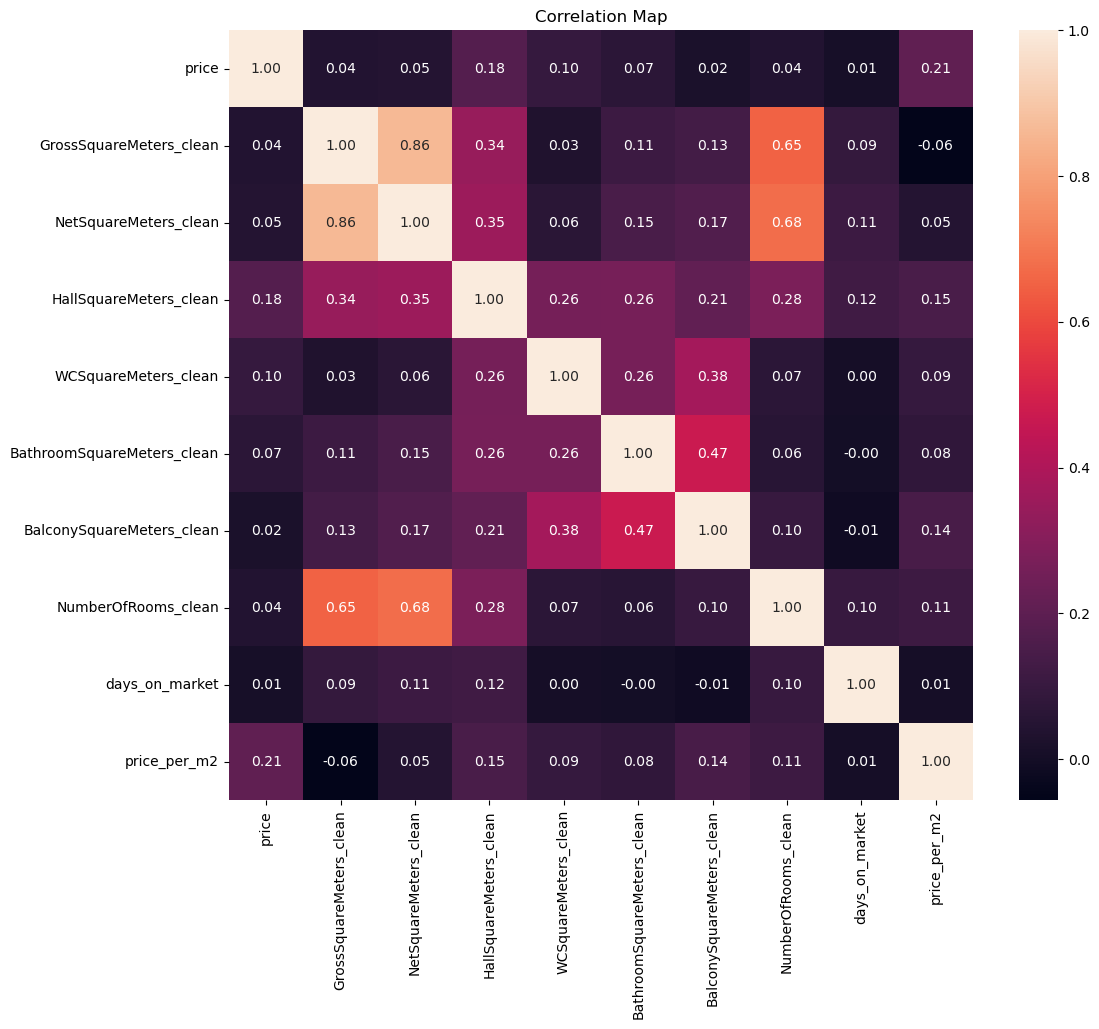

In [78]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_to_keep].corr(), annot=True, fmt=".2f")
plt.title("Correlation Map")
plt.show()
